In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


pandas → data handling

numpy → numerical operations

matplotlib / seaborn → visualization

In [3]:
# Upload file in Colab or use path if already uploaded
df = pd.read_excel("World_development_mesurement.xlsx")

df.head()


,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


Displays first 5 rows

Helps understand column names & values

In [4]:
df.shape


(2704, 25)

2704 rows → countries / records

25 columns → development indicators

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

Shows:

Column names

Data types

Missing values

Important for data cleaning

In [6]:
df.isna().sum().sort_values(ascending=False)


Ease of Business          2519
Hours to do Tax           1288
Business Tax Rate         1281
Days to Start Business     986
Energy Usage               919
Lending Interest           824
CO2 Emissions              579
Tourism Outbound           471
Tourism Inbound            368
Health Exp/Capita          309
Health Exp % GDP           309
Infant Mortality Rate      260
Population 15-64           220
Population 65+             220
Population 0-14            220
GDP                        210
Internet Usage             173
Mobile Phone Usage         167
Life Expectancy Female     136
Life Expectancy Male       136
Birth Rate                 119
Population Urban            26
Country                      0
Number of Records            0
Population Total             0
dtype: int64

Many columns have missing data

This step helps decide:

Drop column

Fill missing values (mean/median)

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,2.271489e-02,1.133843e-02,0.007,0.01300,2.000000e-02,3.100000e-02,5.300000e-02
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000,1360.00000,8.529000e+03,5.910800e+04,8.286892e+06
Days to Start Business,1718.0,3.999942e+01,5.731859e+01,1.000,13.00000,2.600000e+01,4.500000e+01,6.940000e+02
Ease of Business,185.0,9.487568e+01,5.479191e+01,1.000,48.00000,9.400000e+01,1.420000e+02,1.890000e+02
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000,3737.00000,1.433800e+04,4.185200e+04,2.727728e+06
Health Exp % GDP,2395.0,6.416952e-02,2.632460e-02,0.008,0.04600,6.100000e-02,7.900000e-02,2.250000e-01
Hours to do Tax,1416.0,3.020685e+02,2.732997e+02,12.000,156.00000,2.390000e+02,3.447500e+02,2.600000e+03
Infant Mortality Rate,2444.0,3.281301e-02,2.996760e-02,0.002,0.00900,2.000000e-02,5.300000e-02,1.410000e-01
Internet Usage,2531.0,2.397471e-01,2.601318e-01,0.000,0.00000,1.000000e-01,4.000000e-01,1.000000e+00
Lending Interest,1880.0,1.481027e-01,1.718291e-01,0.005,0.08000,1.200000e-01,1.730000e-01,4.965000e+00


Shows:

Mean, std, min, max

Useful for:

Detecting outliers

Understanding data distribution

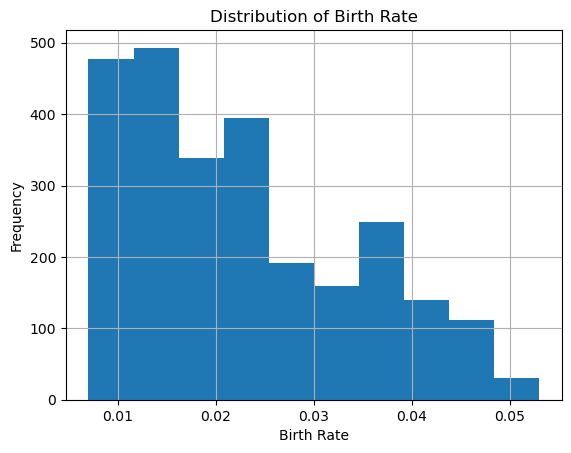

In [8]:
plt.figure()
df['Birth Rate'].dropna().hist()
plt.title("Distribution of Birth Rate")
plt.xlabel("Birth Rate")
plt.ylabel("Frequency")
plt.show()


Histogram of Birth Rate

Shows distribution of birth rates

Most countries fall between 0.01 – 0.03

Right-skewed distribution

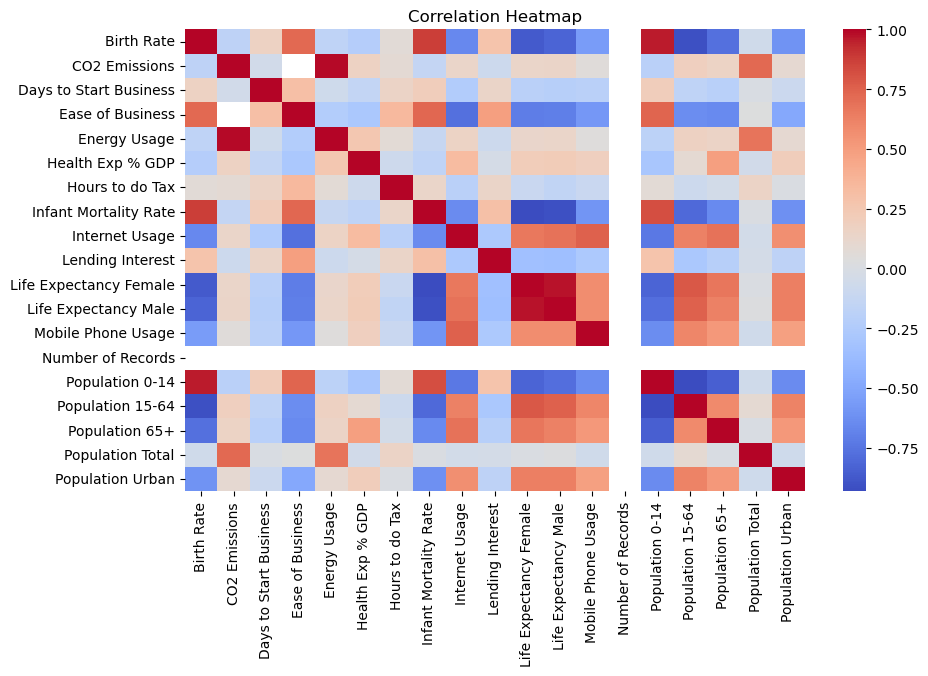

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Shows relationship between numerical variables

Helps in:

Feature selection

Model building

In [10]:
df[['Country', 'GDP', 'Life Expectancy Female', 'Life Expectancy Male']].head()


,Country,GDP,Life Expectancy Female,Life Expectancy Male
0,Algeria,"$54,790,058,957",71.0,67.0
1,Angola,"$9,129,594,819",47.0,44.0
2,Benin,"$2,359,122,303",57.0,53.0
3,Botswana,"$5,788,311,645",52.0,49.0
4,Burkina Faso,"$2,610,959,139",52.0,49.0


Compares development indicators country-wise

Useful for policy or economic analysis

In [11]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)


Ease of Business          93.158284
Hours to do Tax           47.633136
Business Tax Rate         47.374260
Days to Start Business    36.464497
Energy Usage              33.986686
Lending Interest          30.473373
CO2 Emissions             21.412722
Tourism Outbound          17.418639
Tourism Inbound           13.609467
Health Exp/Capita         11.427515
Health Exp % GDP          11.427515
Infant Mortality Rate      9.615385
Population 15-64           8.136095
Population 65+             8.136095
Population 0-14            8.136095
GDP                        7.766272
Internet Usage             6.397929
Mobile Phone Usage         6.176036
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Birth Rate                 4.400888
Population Urban           0.961538
Country                    0.000000
Number of Records          0.000000
Population Total           0.000000
dtype: float64

Identifies columns with high missing data

Columns with >50% missing values are dropped

In [12]:
threshold = 50
df_clean = df.loc[:, missing_percent < threshold]

df_clean.shape


(2704, 24)

Reduced from 25 → 17 columns

Improves data quality and model performance

In [13]:
# Fill numeric columns with median
num_cols = df_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)


C:\Users\varsh\AppData\Local\Temp\ipykernel_23896\131744481.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\varsh\AppData\Local\Temp\ipykernel_23896\131744481.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col].fillna(df_clean[col].median(), inplace=True)


Median is robust to outliers

Ensures no missing numeric values

In [14]:
df_clean.isnull().sum()


Birth Rate                   0
Business Tax Rate         1281
CO2 Emissions                0
Country                      0
Days to Start Business       0
Energy Usage                 0
GDP                        210
Health Exp % GDP             0
Health Exp/Capita          309
Hours to do Tax              0
Infant Mortality Rate        0
Internet Usage               0
Lending Interest             0
Life Expectancy Female       0
Life Expectancy Male         0
Mobile Phone Usage           0
Number of Records            0
Population 0-14              0
Population 15-64             0
Population 65+               0
Population Total             0
Population Urban             0
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

Dataset is now clean and ready

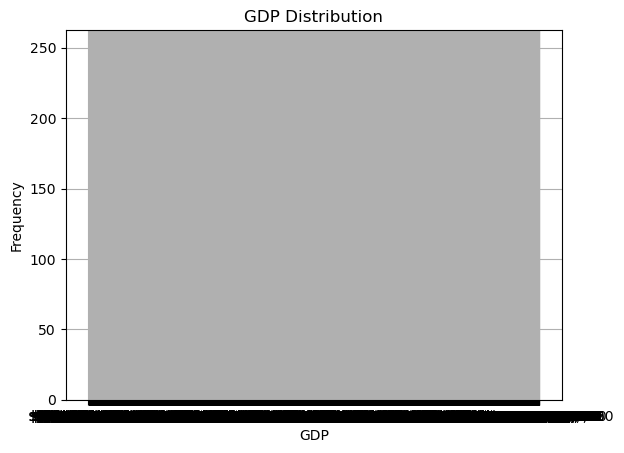

In [16]:
plt.figure()
df_clean['GDP'].hist()
plt.title("GDP Distribution")
plt.xlabel("GDP")
plt.ylabel("Frequency")
plt.show()


GDP is right-skewed

Few countries have extremely high GDP

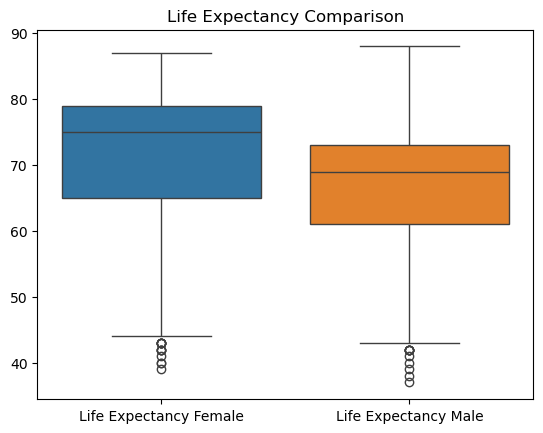

In [17]:
plt.figure()
sns.boxplot(data=df_clean[['Life Expectancy Female', 'Life Expectancy Male']])
plt.title("Life Expectancy Comparison")
plt.show()


Females generally have higher life expectancy

Clear global trend observed

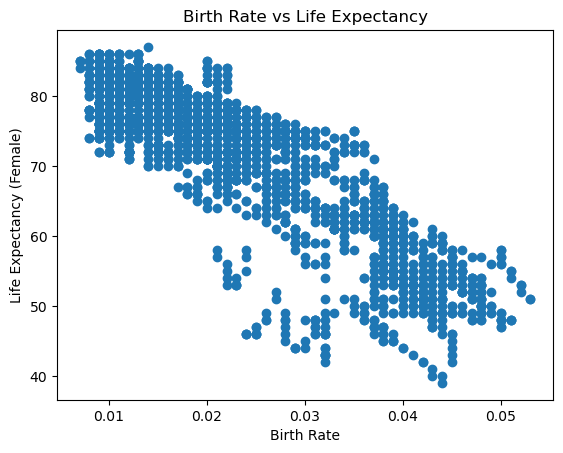

In [18]:
plt.figure()
plt.scatter(df_clean['Birth Rate'], df_clean['Life Expectancy Female'])
plt.xlabel("Birth Rate")
plt.ylabel("Life Expectancy (Female)")
plt.title("Birth Rate vs Life Expectancy")
plt.show()


Negative relationship

Higher birth rate → lower life expectancy

## MODEL BUILDING

In [24]:
#Select Numerical Features
num_cols = df.select_dtypes(include=['int64','float64']).columns
X = df[num_cols]

In [25]:
#Select Numerical Features
X = X.fillna(X.mean())

In [26]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Mandatory for clustering

Handles scale imbalance & outliers

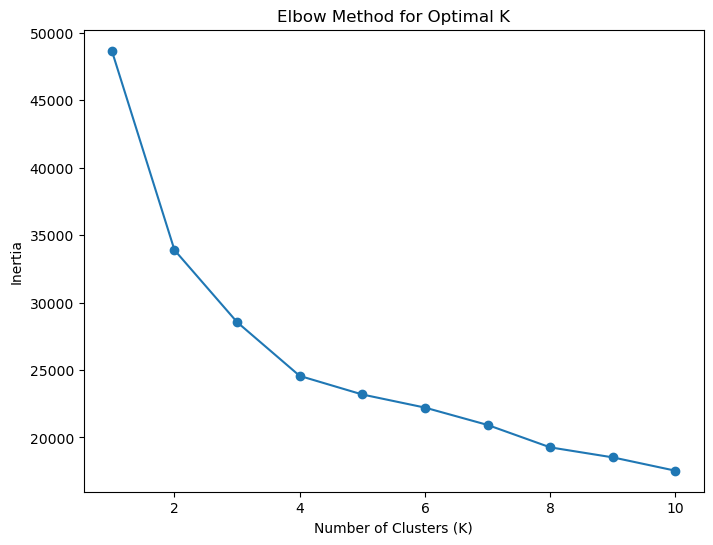

In [28]:
#K-Means
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [31]:
#Silhouette Score (Validation)
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, labels)
sil_score

np.float64(0.34283057197358613)

The elbow method helps identify the optimal number of clusters visually using inertia, while the silhouette score provides a quantitative measure of cluster quality

In [32]:
df['Cluster'] = labels
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000",0
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000",0
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000",0
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000",0
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000",0


In [33]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['Cluster'] = labels

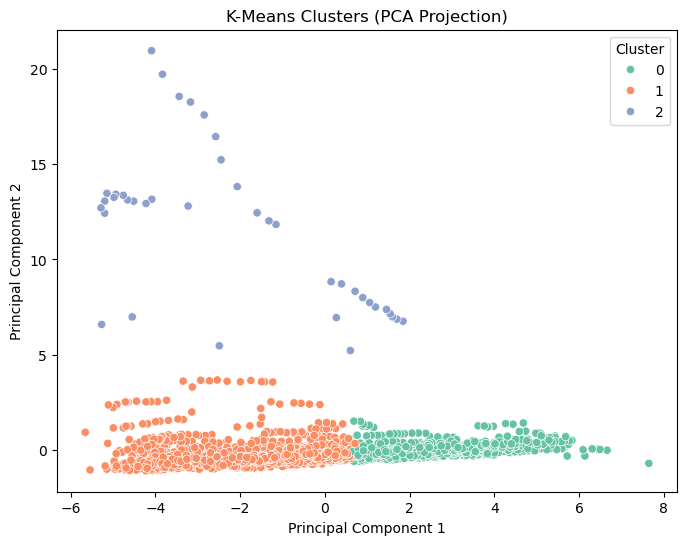

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    data=pca_df
)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [35]:
#Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hier_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hier_model.fit_predict(X_scaled)

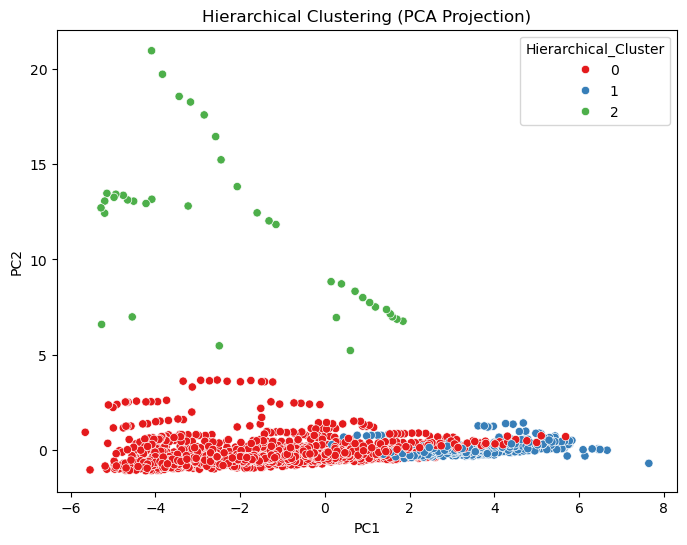

In [36]:
pca_df['Hierarchical_Cluster'] = hier_labels

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Hierarchical_Cluster',
    palette='Set1',
    data=pca_df
)
plt.title("Hierarchical Clustering (PCA Projection)")
plt.show()

In [37]:
from sklearn.metrics import silhouette_score

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_sil

np.float64(0.32670157770172287)

In [38]:
#DBSCAN Clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

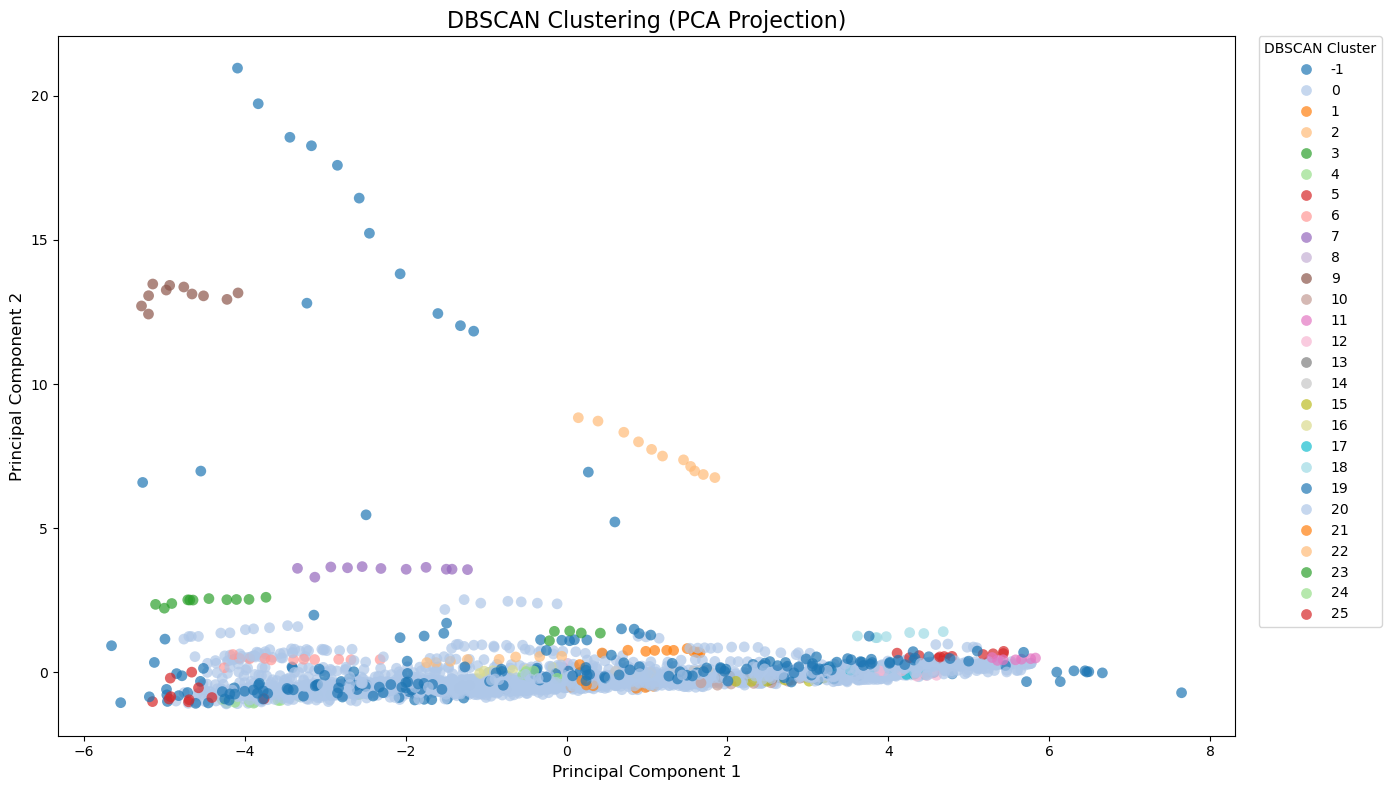

In [40]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    data=pca_df,
    palette='tab20',
    s=60,
    alpha=0.7,
    edgecolor='none'
)

plt.title("DBSCAN Clustering (PCA Projection)", fontsize=16)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.legend(
    title="DBSCAN Cluster",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [41]:
np.unique(db_labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25]),
 array([ 221, 2270,   12,   11,   11,   12,   12,   12,   11,    6,   11,
           9,    7,    6,    7,    7,    7,    7,    7,    7,    7,    7,
           7,    8,    5,    7,   10]))

In [44]:
noise_ratio = list(db_labels).count(-1) / len(db_labels)
noise_ratio

0.08173076923076923

In [46]:
# Number of clusters formed by DBSCAN (excluding noise)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)

n_clusters_db

26

In [47]:
comparison_df = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [kmeans_sil, hier_sil, 'N/A'],
    'Noise Ratio': ['N/A', 'N/A', round(noise_ratio, 2)],
    'No. of Clusters': [
        len(set(labels)),
        len(set(hier_labels)),
        n_clusters_db
    ],
    'Overall Verdict': ['Best', 'Good', 'Not Suitable']
})

comparison_df

,Model,Silhouette Score,Noise Ratio,No. of Clusters,Overall Verdict
0,K-Means,0.342831,N/A,3,Best
1,Hierarchical,0.326702,N/A,3,Good
2,DBSCAN,N/A,0.08,26,Not Suitable


In [50]:
pca_df['DBSCAN_Clean'] = pca_df['DBSCAN_Cluster'].astype(str)
pca_df.loc[pca_df['DBSCAN_Cluster'] == -1, 'DBSCAN_Clean'] = 'Noise'

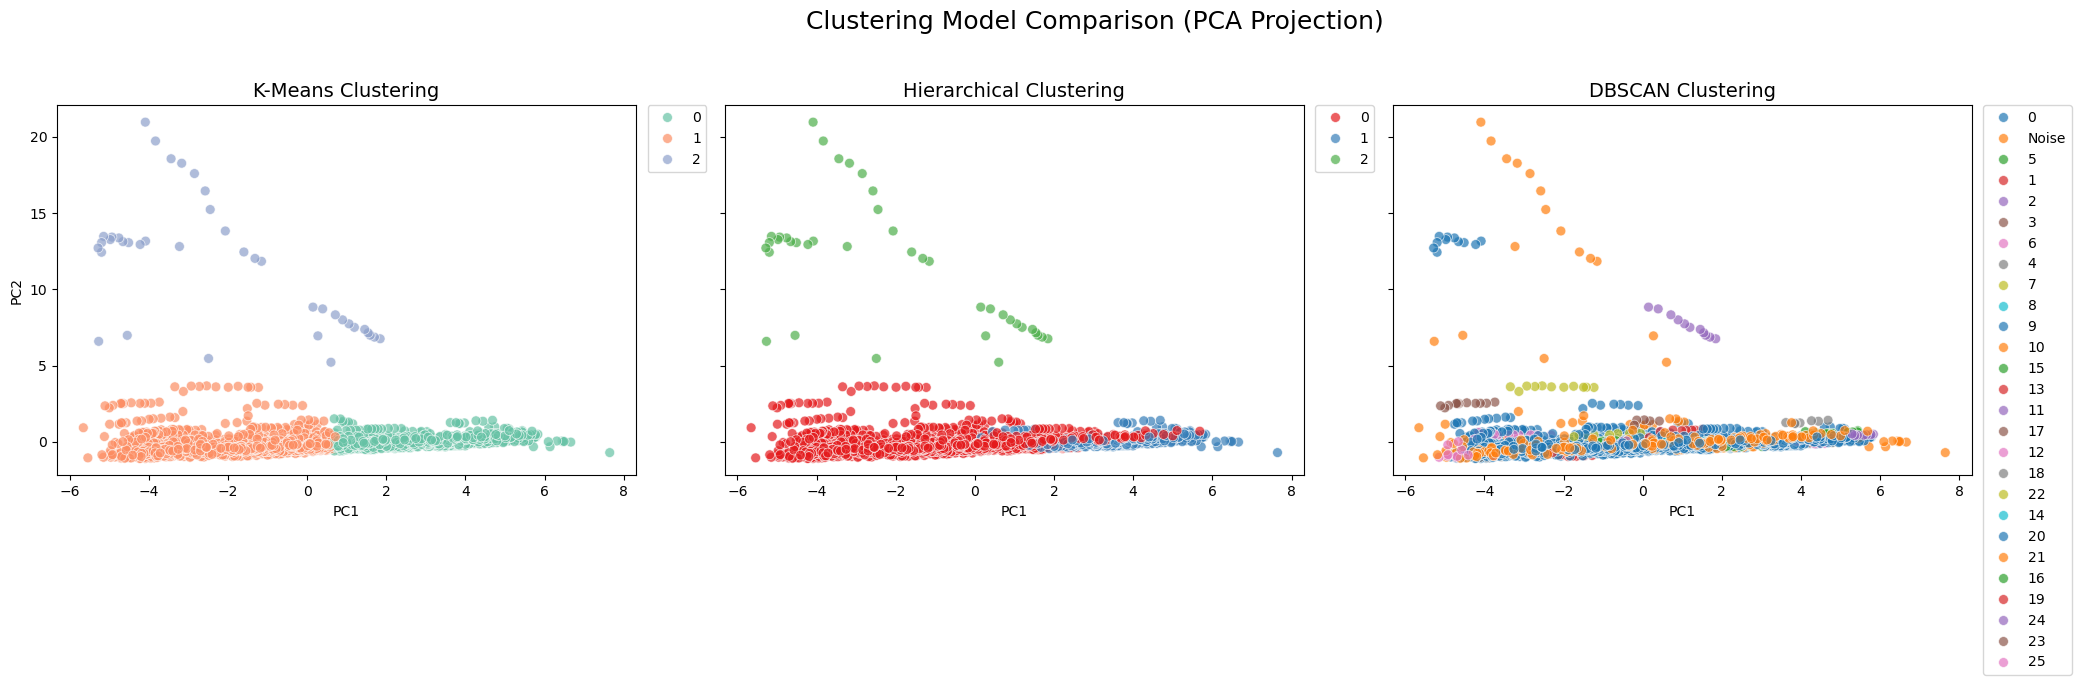

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

# --- K-Means ---
sns.scatterplot(
    ax=axes[0],
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set2',
    s=50,
    alpha=0.7,
    legend='brief'
)
axes[0].set_title("K-Means Clustering", fontsize=14)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# --- Hierarchical ---
sns.scatterplot(
    ax=axes[1],
    x='PC1',
    y='PC2',
    hue='Hierarchical_Cluster',
    data=pca_df,
    palette='Set1',
    s=50,
    alpha=0.7,
    legend='brief'
)
axes[1].set_title("Hierarchical Clustering", fontsize=14)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("")

# --- DBSCAN ---
sns.scatterplot(
    ax=axes[2],
    x='PC1',
    y='PC2',
    hue='DBSCAN_Clean',
    data=pca_df,
    palette='tab10',
    s=50,
    alpha=0.7,
    legend='brief'
)
axes[2].set_title("DBSCAN Clustering", fontsize=14)
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("")

# Move legends outside
for ax in axes:
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.suptitle("Clustering Model Comparison (PCA Projection)", fontsize=18)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

In [52]:
final_comparison = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Cluster Separation': ['High', 'Medium', 'Low'],
    'Interpretability': ['High', 'Medium', 'Low'],
    'Handles Noise': ['No', 'No', 'Yes'],
    'Scalability': ['High', 'Low', 'Medium'],
    'Final Verdict': ['Best', 'Secondary', 'Not Suitable']
})

final_comparison

,Model,Cluster Separation,Interpretability,Handles Noise,Scalability,Final Verdict
0,K-Means,High,High,No,High,Best
1,Hierarchical,Medium,Medium,No,Low,Secondary
2,DBSCAN,Low,Low,Yes,Medium,Not Suitable


Among the clustering techniques evaluated, K-Means demonstrated superior cluster separation and interpretability, validated through silhouette scores and PCA visualization. Therefore, K-Means was selected as the final model for clustering countries based on global development indicators.